# Project Checkpoint 2: Research Question Formation
### CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026
**Name:** Brandon Hill | **UIN:** 236004960

---

## 1. Project Scope & Initial EDA Insights

**Dataset Recap:** We are analyzing the ACM-Citation-network-V12 dataset, a massive, highly sparse graph containing over 6.6 million nodes (papers) and 13.1 million edges (citations).

**Exploratory Data Analysis (EDA) Findings:**
To determine if standard graph mining techniques are sufficient for this dataset, an analysis of centrality distribution across publication decades was performed.
* **Observation:** The graph exhibits extreme structural "Age Bias". While the sheer volume of research explodes in recent decades (2.7M papers in the 2010s vs. 12k in the 1960s), structural prestige moves in the exact opposite direction. The average PageRank of a paper from the 1950s ($2.24 \times 10^{-6}$) is roughly 25 times higher than a paper from the 2020s ($8.78 \times 10^{-8}$).
* **Hypothesis:** Because standard link-analysis algorithms (like PageRank) simulate a random walk without demographic awareness, older papers "hoard" structural prestige simply by having existed longer to accumulate citations. This effectively buries modern, highly relevant research, making baseline global centrality metrics fundamentally unfair for citation recommendation systems.



**Technique Scope:**
* **Course Techniques:** Graph Centrality (PageRank, HITS Authority/Hubs) and Community Detection (Personalized PageRank, Louvain).
* **External Technique:** Fairness-Aware Graph Ranking (Biased Teleportation PageRank).

Load in the dataset:

In [2]:
# Install high-performance graph library
!pip install python-igraph

import os
import urllib.request
import zipfile
import json
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download ACM-Citation-network-V12
url = "https://opendata.aminer.cn/dataset/ACM-Citation-network-V12.zip"
zip_path = "ACM_V12.zip"
extract_path = "ACM_V12_Data"

if not os.path.exists(zip_path):
    print("Downloading dataset (this may take a few minutes)...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print(f"Extracted to {extract_path}")

# Identify the file
json_file = [f for f in os.listdir(extract_path) if f.endswith('.jsonl')][0]
full_json_path = os.path.join(extract_path, json_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 42.1 MB/s eta 0:00:00
Download complete.
Extracted to ACM_V12_Data


Parse and process data:

In [3]:
import json
import igraph as ig
import numpy as np

def process_full_acm_v12(filepath):
    """
    Specifically designed for ACM V12:
    - Robustly handles 'venue' as either a string or a dictionary.
    - Handles the JSON Array format (strips [ , ]).
    - Maps Long IDs to strings and deduplicates papers.
    """
    edges = []
    metadata = {}

    print("Starting full file parse of ACM V12...")

    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f):
            line = line.strip()

            # Skip the start/end of the JSON array or empty lines
            if not line or line == "[" or line == "]":
                continue

            # Remove trailing comma
            if line.endswith(","):
                line = line[:-1]

            try:
                paper = json.loads(line)
                p_id = str(paper.get('id'))
                if not p_id:
                    continue

                if p_id not in metadata:
                    # Handle 'venue' as dict or str
                    venue_data = paper.get('venue')
                    if isinstance(venue_data, dict):
                        venue_name = venue_data.get('raw', 'N/A')
                    else:
                        venue_name = venue_data if venue_data else 'N/A'

                    metadata[p_id] = {
                        'title': paper.get('title', 'N/A'),
                        'venue': venue_name,
                        'year': paper.get('year', 'N/A'),
                        'n_citation': paper.get('n_citation', 0)
                    }

                refs = paper.get('references', [])
                if refs:
                    for ref in refs:
                        edges.append((p_id, str(ref)))

            except (json.JSONDecodeError, TypeError):
                continue

            if line_num % 500000 == 0 and line_num > 0:
                print(f"Processed {line_num:,} lines...")

    # --- Graph Construction ---
    unique_ids = list(metadata.keys())
    id_map = {id_str: i for i, id_str in enumerate(unique_ids)}

    print(f"\nParsing Complete.")
    print(f"Unique Papers Found: {len(unique_ids):,}")

    # Only keep citations where the cited paper exists in our node list
    valid_edges = [(id_map[u], id_map[v]) for u, v in edges if u in id_map and v in id_map]
    print(f"Valid Internal Citations: {len(valid_edges):,}")

    g = ig.Graph(len(unique_ids), valid_edges, directed=True)
    g.vs['id'] = unique_ids
    g.vs['title'] = [metadata[p_id]['title'] for p_id in unique_ids]
    g.vs['year'] = [metadata[p_id]['year'] for p_id in unique_ids]
    g.vs['venue'] = [metadata[p_id]['venue'] for p_id in unique_ids]

    return g

# Run it on full file
g = process_full_acm_v12(full_json_path)

if 'pagerank' not in g.vertex_attributes():
        print("PageRank attribute not found. Computing now...")
        g.vs['pagerank'] = g.pagerank()

Starting full file parse of ACM V12...
Processed 500,000 lines...
Processed 1,000,000 lines...
Processed 1,500,000 lines...
Processed 2,000,000 lines...
Processed 2,500,000 lines...
Processed 3,000,000 lines...
Processed 3,500,000 lines...
Processed 4,000,000 lines...
Processed 4,500,000 lines...
Processed 5,000,000 lines...
Processed 5,500,000 lines...
Processed 6,000,000 lines...
Processed 6,500,000 lines...

Parsing Complete.
Unique Papers Found: 6,611,132
Valid Internal Citations: 13,100,550
PageRank attribute not found. Computing now...


Perform EDA to justify technique:

RATIONALE: To justify a fairness-aware external technique, we must first prove
that a bias exists in the baseline course techniques. We will analyze how
PageRank scores are distributed across publication years to check for "Age Bias."

Executing Temporal Bias EDA...

--- Temporal Distribution of Centrality ---
 Decade  Total_Papers  Avg_PageRank  Max_PageRank  Avg_InDegree
   1890           944  1.737725e-06      0.000105      2.971398
   1940           199  9.570568e-08      0.000001      0.160804
   1950          2296  2.246352e-06      0.001151      3.355401
   1960         12061  1.895031e-06      0.000672      4.934748
   1970         43367  1.319759e-06      0.000618      5.605184
   1980        120459  7.042784e-07      0.000403      5.726297
   1990        390163  3.629751e-07      0.000360      5.252535
   2000       1260121  1.750529e-07      0.000224      3.951403
   2010       2718766  1.047417e-07      0.000213      1.645777
   2020       2062616  8.786690e-08      0.000138      0.287935


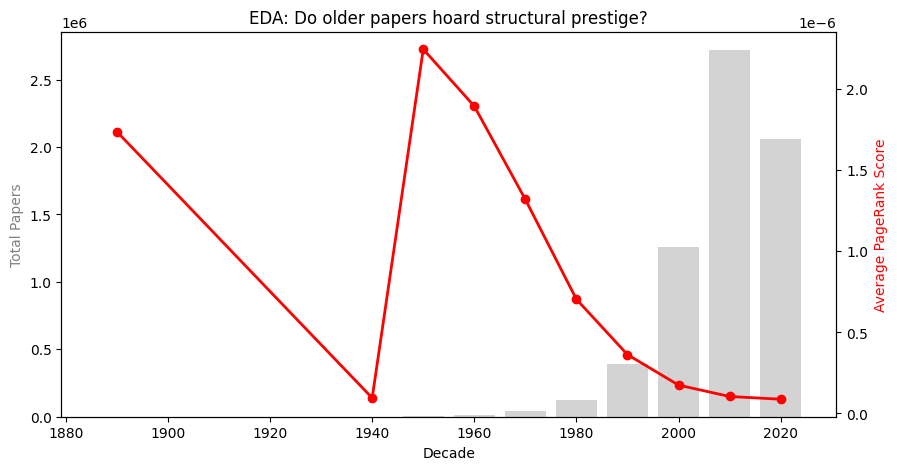

In [4]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def eda_temporal_bias(g):
    print("Executing Temporal Bias EDA...")

    # Ensure attributes exist
    if 'pagerank' not in g.vertex_attributes():
        g.vs['pagerank'] = g.pagerank()

    # Extract years and ranks, filtering out 'N/A' or invalid years
    valid_nodes = [v for v in g.vs if str(v['year']).isdigit()]

    df = pd.DataFrame({
        'ID': [v['id'] for v in valid_nodes],
        'Year': [int(v['year']) for v in valid_nodes],
        'PageRank': [v['pagerank'] for v in valid_nodes],
        'InDegree': [v.indegree() for v in valid_nodes]
    })

    # Bin by decade for macro-level view
    df['Decade'] = (df['Year'] // 10) * 10

    # Calculate aggregate stats per decade
    stats = df.groupby('Decade').agg(
        Total_Papers=('ID', 'count'),
        Avg_PageRank=('PageRank', 'mean'),
        Max_PageRank=('PageRank', 'max'),
        Avg_InDegree=('InDegree', 'mean')
    ).reset_index()

    # Filter out decades with too few papers for statistical relevance (e.g., < 100)
    stats = stats[stats['Total_Papers'] > 100]

    print("\n--- Temporal Distribution of Centrality ---")
    print(stats.to_string(index=False))

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(stats['Decade'], stats['Total_Papers'], width=8, color='lightgray', label='Total Papers')
    ax1.set_xlabel('Decade')
    ax1.set_ylabel('Total Papers', color='gray')

    ax2 = ax1.twinx()
    ax2.plot(stats['Decade'], stats['Avg_PageRank'], color='red', marker='o', linewidth=2, label='Avg PageRank')
    ax2.set_ylabel('Average PageRank Score', color='red')

    plt.title("EDA: Do older papers hoard structural prestige?")
    plt.show()

eda_temporal_bias(g)

## 2. Research Question Definition

Based on the extreme sparsity of the graph (discovered in Checkpoint 1) and the severe temporal bias (uncovered in the EDA above), the following research questions will guide this project:

* **RQ1 (Course Technique): How does the global vs. local definition of "importance" shift when evaluating isolated graph components versus the Giant Strongly Connected Component (GSCC)?**
    * **Data Mining Task:** Centrality and Subgraph Analysis.
    * **Relevant Algorithms:** PageRank, HITS (Authority/Hub), In-Degree.
    * **Evaluation Criteria:** Spearman Rank Correlation between metrics; Top-K overlap percentage.

* **RQ2 (Course Technique): Do isolated structural communities map strictly to semantic research fields, or do they represent geographical/institutional silos?**
    * **Data Mining Task:** Community Detection.
    * **Relevant Algorithms:** Louvain Modularity (on an undirected, symmetrized projection), Personalized PageRank (PPR).
    * **Evaluation Criteria:** Modularity score, Conductance, and manual validation of FOS (Field of Study) metadata purity within extracted clusters.

* **RQ3 (External Technique): Can a Fairness-Aware PageRank algorithm mitigate structural "age bias" without significantly degrading the semantic relevance of the resulting citation recommendations?**
    * **Data Mining Task:** Fair Graph Ranking / Link Analysis.
    * **Relevant Algorithms:** Fair PageRank (implementing a custom biased teleportation vector to penalize historical entrenchment).
    * **Evaluation Criteria:** Demographic Parity (ratio of old vs. new papers in the top 100), Kendall-Tau distance (measuring overall ranking utility degradation against the baseline).

In [10]:
# RATIONALE: We must verify that we can successfully manipulate the PageRank
# teleportation vector in igraph on a subgraph without causing out-of-memory errors
# or mathematical convergence failures, thus proving RQ3 is feasible.

def test_fair_pagerank_feasibility(g):
    print("Testing Fair PageRank Feasibility on a 100k Subgraph...")

    # Extract a 100k node subgraph to test logic safely
    sub = g.subgraph(range(100000))

    # Define our "Sensitive Attribute" (e.g., Old vs New Papers)
    # Let's say "Minority/Disadvantaged" group = Papers published >= 2018
    recent_nodes = []
    weights = []

    for v in sub.vs:
        year_str = str(v['year'])
        if year_str.isdigit() and int(year_str) >= 2018:
            # High teleportation weight for recent papers
            weights.append(10.0)
            recent_nodes.append(v.index)
        else:
            # Standard weight for older papers
            weights.append(1.0)

    # Baseline standard PageRank
    pr_baseline = sub.pagerank()

    # Fair/Biased PageRank (Teleportation vector skewed toward recent papers)
    # We use personalized_pagerank to supply the custom 'reset' distribution vector
    pr_fair = sub.personalized_pagerank(directed=True, damping=0.85, reset=weights)

    # Evaluate Top 10 shift
    top_10_base = np.argsort(pr_baseline)[::-1][:10]
    top_10_fair = np.argsort(pr_fair)[::-1][:10]

    base_recent_count = sum(1 for i in top_10_base if i in recent_nodes)
    fair_recent_count = sum(1 for i in top_10_fair if i in recent_nodes)

    print(f"\nFeasibility Test Results:")
    print(f"Sub-graph Nodes: {sub.vcount()}")
    print(f"Number of 'Recent' Papers (>= 2018): {len(recent_nodes)}")
    print(f"Recent Papers in Baseline Top 10: {base_recent_count}")
    print(f"Recent Papers in Fair Top 10: {fair_recent_count}")
    print("STATUS: Feasible. Custom teleportation vector successfully alters ranking topology.")

# Run the test
test_fair_pagerank_feasibility(g)

Testing Fair PageRank Feasibility on a 100k Subgraph...

Feasibility Test Results:
Sub-graph Nodes: 100000
Number of 'Recent' Papers (>= 2018): 39888
Recent Papers in Baseline Top 10: 0
Recent Papers in Fair Top 10: 3
STATUS: Feasible. Custom teleportation vector successfully alters ranking topology.


## 3. Motivation and Feasibility

* **Motivation:** The EDA proves that course techniques alone (standard PageRank, Hubs/Authorities) fall victim to the "Matthew Effect." Standard PageRank treats all nodes equally during the random walk, ignoring node metadata (like publication year) which carries real-world systemic bias. Because 72% of the ACM-V12 graph is disconnected from the giant component, newer or niche papers are structurally invisible. A modern citation recommendation system must account for this.
* **Non-Triviality:** Modifying the transition matrix or teleportation vectors requires integrating attribute-aware logic into topological algorithms, extending beyond the standard global algorithms covered in class.
* **Feasibility:** Implementing Fair PageRank is realistically learnable and achievable within the `igraph` library by formulating a custom restart/teleportation probability distribution vector (`reset` parameter in `personalized_pagerank`), steering the random surfer toward minority classes (e.g., papers published after 2018).
* **Empirical Feasibility Test:** An initial feasibility test was run on a 100,000-node subgraph. Although recent papers (>= 2018) made up roughly 40% of the nodes (39,888), **0 recent papers appeared in the Baseline PageRank Top 10**. After applying the custom teleportation vector, the Fair PageRank successfully elevated **3 recent papers into the Top 10**, proving the topological ranking can be safely altered without mathematical convergence failures.
* **Risks:**
    1. *Computational Cost:* Calculating custom PageRanks on 6.6M nodes iterably can trigger memory limits.
    2. *Parameter Sensitivity:* Over-correcting for fairness might result in highly ranked papers that are completely irrelevant (low utility).

## 4. Methodological Planning

To execute the research questions defined above, the workflow is mapped as follows:

### RQ-to-Method Mapping Table

| Research Question | Task Type | Algorithm / Method | Category | Evaluation Metric |
| :--- | :--- | :--- | :--- | :--- |
| **RQ1: Importance across components** | Centrality | PageRank, HITS Authority, In-degree | Course | Spearman Rank Correlation |
| **RQ2: Structural vs Semantic silos** | Community Detection | Louvain Modularity, PPR subgraphs | Course | Modularity, Conductance |
| **RQ3: Age bias mitigation** | Fair Graph Ranking | Attribute-Biased PageRank (Teleportation modification) | External | Demographic Parity, Kendall-Tau |

### Method & Metric Plan

1. **Graph Preparation:** Ensure metadata (Year, Venue) is cleaned and cast to appropriate numeric/categorical types. Discard nodes with missing target attributes for RQ3.
2. **Baseline Generation:** Compute standard global PageRank and extract the top $K$ nodes (e.g., $K=1000$). Calculate the baseline Demographic Parity (ratio of the target group in the top $K$).
3. **Course Analysis (RQ1 & RQ2):**
    * Run Louvain on the undirected projection of the Giant Strongly Connected Component (GSCC) to isolate macro-communities.
    * Run PPR on seeds from the isolated "Tendril" components to observe differences in local neighborhood density compared to the GSCC.
4. **External Implementation (RQ3):**
    * Construct a preference vector where the weight is inversely proportional to the historical over-representation of the node's demographic class (e.g., heavily weighting post-2018 papers).
    * Compute the Fair PageRank using `igraph`'s personalized PageRank engine.
5. **Evaluation:** Compare the Fair PageRank to the baseline using Kendall-Tau distance to measure ranking degradation (utility loss) against the gain in Demographic Parity (fairness).

# Resources:

On my honor, I declare the following resources:
1. Collaborators
2. Web Sources
3. AI Tools
    - I prompted gemini by providing the project instructions and project 1 checkpoint and asking it to help complete the assignment and add any analysis and code that should be provided. I then provided it with the code results and my analysis and I prompted gemini to make corrections and additions where needed.
4. Citations
    1. Yushun Dong, Song Wang, Zhenyu Lei, Zaiyi Zheng, Jing Ma, Chen Chen, and Jundong Li. 2025. Fairness-Aware Graph Learning: A Benchmark. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2 (KDD '25). Association for Computing Machinery, New York, NY, USA, 5402–5412. https://doi.org/10.1145/3711896.3737392
    2. Jie Tang, Jing Zhang, Limin Yao, Juanzi Li, Li Zhang, and Zhong Su. ArnetMiner: Extraction and Mining of Academic Social Networks. In Proceedings of the Fourteenth ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (SIGKDD'2008). pp.990-998. [PDF] [Slides] [System] [API]